In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA as SklearnPCA

from pca import PCA

np.set_printoptions(precision=4, suppress=True)

data = load_iris()
X, y, target_names = data.data, data.target, data.target_names
X.shape

(150, 4)

In [2]:
n_components = 4

pca_eigen = PCA(n_components=n_components)
pca_eigen.fit(X, method='eigen')

pca_svd = PCA(n_components=n_components)
pca_svd.fit(X, method='svd')

pca_sklearn = SklearnPCA(n_components=n_components)
pca_sklearn.fit(X)


def sign_align(components, reference):
    """Flip each component's sign to match the reference's sign convention."""
    signs = np.sign(np.sum(components * reference, axis=0))
    signs[signs == 0] = 1
    return components * signs


ref = pca_sklearn.components_.T  # (p, n_components)
comp_eigen = sign_align(pca_eigen.components, ref)
comp_svd = sign_align(pca_svd.components, ref)

print("Max abs diff in components   (eigen vs sklearn):", np.max(np.abs(comp_eigen - ref)))
print("Max abs diff in components   (svd   vs sklearn):", np.max(np.abs(comp_svd - ref)))
print()
print("Explained variance ratio (eigen):  ", pca_eigen.explained_variance_ratio)
print("Explained variance ratio (svd):    ", pca_svd.explained_variance_ratio)
print("Explained variance ratio (sklearn):", pca_sklearn.explained_variance_ratio_)
print()
print("Max abs diff in explained variance ratio (eigen vs sklearn):",
      np.max(np.abs(pca_eigen.explained_variance_ratio - pca_sklearn.explained_variance_ratio_)))
print("Max abs diff in explained variance ratio (svd   vs sklearn):",
      np.max(np.abs(pca_svd.explained_variance_ratio - pca_sklearn.explained_variance_ratio_)))

Max abs diff in components   (eigen vs sklearn): 1.1191048088221578e-13
Max abs diff in components   (svd   vs sklearn): 1.1146639167236572e-13

Explained variance ratio (eigen):   [0.9246 0.0531 0.0171 0.0052]
Explained variance ratio (svd):     [0.9246 0.0531 0.0171 0.0052]
Explained variance ratio (sklearn): [0.9246 0.0531 0.0171 0.0052]

Max abs diff in explained variance ratio (eigen vs sklearn): 7.216449660063518e-15
Max abs diff in explained variance ratio (svd   vs sklearn): 6.8833827526759706e-15


In [4]:
from sklearn.decomposition import SparsePCA as SklearnSparsePCA
from pca import SparsePCA

# Two independent latent factors, each driving a block of 3 correlated
# features, plus 4 pure-noise features unrelated to either factor.
np.random.seed(42)
n = 300
noise_level = 0.3
z1 = np.random.randn(n)
z2 = np.random.randn(n)

X_synth = np.empty((n, 10))
X_synth[:, 0:3] = z1[:, None] + noise_level * np.random.randn(n, 3)
X_synth[:, 3:6] = z2[:, None] + noise_level * np.random.randn(n, 3)
X_synth[:, 6:10] = np.random.randn(n, 4)

feature_names = [f"X{i+1}" for i in range(10)]
true_block = np.array([0, 0, 0, 1, 1, 1, -1, -1, -1, -1])  # 0/1: factor id, -1: noise

pca_ord = SklearnPCA(n_components=2).fit(X_synth)

sparse_custom = SparsePCA(n_components=2, alpha=1.0, l1_ratio=0.5, max_iter=200)
sparse_custom.fit(X_synth)

# alpha isn't on the same scale as the custom implementation's (different
# objective), so it's re-tuned here to reach a comparably sparse solution.
sparse_sklearn = SklearnSparsePCA(n_components=2, alpha=5.0, random_state=0, max_iter=1000)
sparse_sklearn.fit(X_synth)

comp_ord = pca_ord.components_.T
comp_custom = sign_align(sparse_custom.components, comp_ord)
comp_sklearn = sign_align(sparse_sklearn.components_.T, comp_ord)

print("Nonzero loadings per component:")
print("  Ordinary PCA:     ", (np.abs(comp_ord) > 1e-2).sum(axis=0))
print("  Custom SparsePCA: ", (np.abs(comp_custom) > 1e-8).sum(axis=0))
print("  sklearn SparsePCA:", (np.abs(comp_sklearn) > 1e-8).sum(axis=0))

Nonzero loadings per component:
  Ordinary PCA:      [10 10]
  Custom SparsePCA:  [3 3]
  sklearn SparsePCA: [3 3]


In [6]:
from pca import KernelPCA
from sklearn.decomposition import KernelPCA as SklearnKernelPCA

gamma = 1.0 / X.shape[1]  # match sklearn's default gamma (1 / n_features)
n_components_k = 4

kpca_custom = KernelPCA(n_components=n_components_k, gamma=gamma)
kpca_custom.fit(X)

kpca_sklearn = SklearnKernelPCA(n_components=n_components_k, kernel='rbf', gamma=gamma)
kpca_sklearn.fit(X)

Xt_kernel_custom = kpca_custom.transform(X)
Xt_kernel_sklearn = kpca_sklearn.transform(X)

signs_k = np.sign(np.sum(Xt_kernel_custom * Xt_kernel_sklearn, axis=0))
signs_k[signs_k == 0] = 1
Xt_kernel_custom_aligned = Xt_kernel_custom * signs_k

print("Max abs diff in eigenvalues (custom vs sklearn):",
      np.max(np.abs(kpca_custom.lambdas - kpca_sklearn.eigenvalues_[:n_components_k])))
print("Max abs diff in projected training data (custom vs sklearn):",
      np.max(np.abs(Xt_kernel_custom_aligned - Xt_kernel_sklearn)))

Max abs diff in eigenvalues (custom vs sklearn): 4.973799150320701e-14
Max abs diff in projected training data (custom vs sklearn): 2.886579864025407e-15


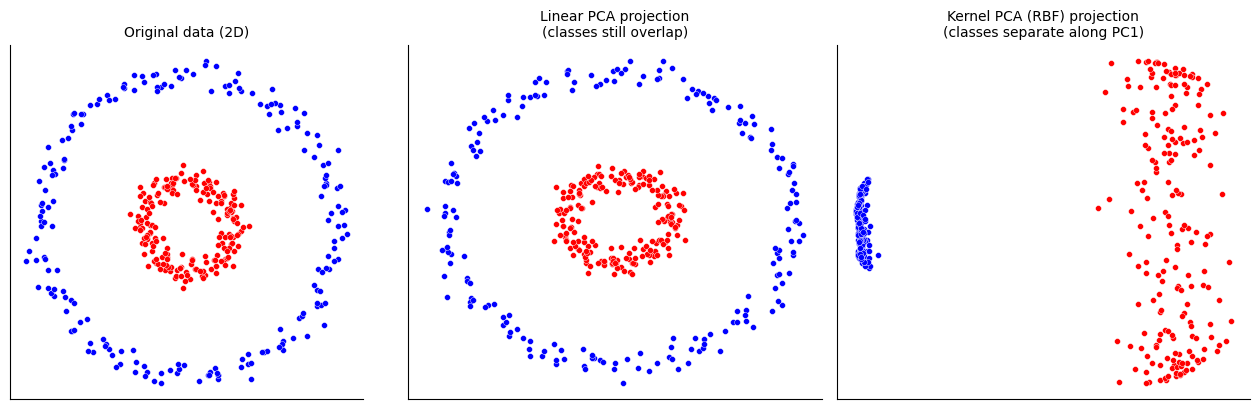

In [8]:
from sklearn.datasets import make_circles

Xc, yc = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=0)

pca_lin = PCA(n_components=2)
pca_lin.fit(Xc, method='eigen')
Xc_lin = pca_lin.transform(Xc.copy())

kpca_demo = KernelPCA(n_components=2, gamma=5)
kpca_demo.fit(Xc)
Xc_kernel = kpca_demo.transform(Xc)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
panels = [
    ("Original data (2D)", Xc),
    ("Linear PCA projection\n(classes still overlap)", Xc_lin),
    ("Kernel PCA (RBF) projection\n(classes separate along PC1)", Xc_kernel),
]
for ax, (title, Xp) in zip(axes, panels):
    for i, color in zip([0, 1], ['b', 'r']):
        mask = yc == i
        ax.scatter(Xp[mask, 0], Xp[mask, 1], s=18, color=color,
                   edgecolors='white', linewidths=0.3)
    ax.set_title(title, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
axes[0].set_aspect('equal')

plt.tight_layout()
plt.show()